# Deep Kernel Learning: Bridging Neural Networks and Gaussian Processes

## 1. Introduction and Motivation

### The Limitation of Standard Gaussian Processes
Gaussian Processes (GPs) are the gold standard for **uncertainty quantification**. They tell us not just *what* they predict, but *how confident* they are. However, standard GPs suffer from a major limitation: **The Kernel Bottleneck**.

Standard kernels (like RBF or Matern) rely on **Euclidean distance** ($||x_i - x_j||$) to measure similarity. They assume that if two input points are close in numerical value, their outputs should be similar. This fails catastrophically when:
1.  **The data is high-dimensional:** (e.g., pixels in an image). Euclidean distance becomes meaningless in high dimensions.
2.  **The data is discontinuous:** (e.g., a step function). A standard GP will over-smooth the jump.
3.  **The data lives on a manifold:** (e.g., a spiral). Points might be "far" in Euclidean space but "close" along the manifold structure.

### The Solution: Deep Kernel Learning (DKL)
Deep Kernel Learning combines the **feature extraction** power of Deep Neural Networks (DNNs) with the **non-parametric flexibility** of Gaussian Processes.

Instead of applying the Kernel directly to the raw input $x$, we first pass $x$ through a Neural Network $h(x;\theta)$ to map it into a **latent embedding space**.

<br>
<img src="embedding.jpeg" width="600" style="display: block; margin: 0 auto">
<br>

*Figure 1: Visualizing the transformation. The Neural Network acts as a Feature Extractor (left), compressing complex inputs into a lower-dimensional "Embedding" (orange box) where the GP can operate effectively.*

Mathematically, the Deep Kernel is defined as:
$$k_{DKL}(x_i, x_j) = k_{base}(h(x_i;\theta), h(x_j;\theta))$$

Where:
* $h(x;\theta)$ is the Neural Network (the "Embedding" layer).
* $k_{base}$ is a standard kernel (e.g., RBF) acting on the *output* of the network.

### What This Notebook Covers
In this pedagogical guide, we will build a DKL framework from scratch using `GPyTorch`. You will learn:

1.  **The Step Function Test:** Comparing how a Standard GP vs. DKL handles sharp discontinuities (1D).
2.  **The "Tearing" of Space:** Visualizing how the Neural Network learns to separate data clusters to help the GP.
3.  **Numerical Stability:** Why we need `float64` precision and Jitter when combining Deep Learning with Probabilistic models.
4.  **Mini-Neural Architecture Search:** A loop to determine if "Deeper" or "Wider" networks actually help the GP, using **Negative Log Likelihood (NLL)** to measure calibration.
5.  **Robust Evaluation:** Using K-Fold Cross Validation to ensure our results are statistically significant.

In [2]:
import torch
import torch.nn as nn
import gpytorch
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold

# Set plotting style
sns.set_style('whitegrid')
%matplotlib inline

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Defining the Models

We define three classes here:
1.  `StandardGP`: A baseline GP with an RBF Kernel.
2.  `DKLModel`: A standard Deep Kernel model with a fixed architecture (50 -> 50 -> 2).
3.  `DynamicDKL`: A flexible DKL class that allows us to inject different neural architectures on the fly (used later for Neural Architecture Search).

In [3]:
# --- 1. Standard GP Model ---
class StandardGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(StandardGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 2. Fixed DKL Model (For Intro Examples) ---
class DKLModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, input_dim=1):
        super(DKLModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        
        # Fixed Neural Network Architecture
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 2)  # Project to 2 Latent Dimensions
        )
        
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        # Normalize to keep GP stable (-1 to 1 scaling)
        projected_x = projected_x - projected_x.min(0)[0]
        projected_x = 2 * (projected_x / projected_x.max(0)[0]) - 1
        
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 3. Dynamic DKL Model (For Architecture Search) ---
class DynamicDKL(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, hidden_layers=[50, 50], activation='relu'):
        super(DynamicDKL, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        
        layers = []
        input_dim = train_x.shape[-1]
        for h_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, h_dim))
            if activation == 'relu': layers.append(nn.ReLU())
            elif activation == 'tanh': layers.append(nn.Tanh())
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 2))
        
        self.feature_extractor = nn.Sequential(*layers)
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))

    def forward(self, x):
        projected_x = self.feature_extractor(x)
        projected_x = projected_x - projected_x.min(0)[0]
        projected_x = 2 * (projected_x / projected_x.max(0)[0]) - 1
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [4]:
# --- helper functions ---
def train_model(model, likelihood, train_x, train_y, iterations=100, lr=0.1, verbose=True):
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(iterations):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if verbose and (i+1) % 50 == 0:
            print(f"Iter {i+1}/{iterations} - Loss: {loss.item():.3f}")

def evaluate_metrics(model, likelihood, x, y):
    model.eval(); likelihood.eval()
    with torch.no_grad():
        pred = likelihood(model(x))
        rmse = torch.sqrt(torch.mean((pred.mean - y)**2)).item()
        # Negative Log Likelihood (Lower is better, measures calibration)
        nll = -pred.log_prob(y).mean().item()
    return rmse, nll

## 3. Example 1: The 1D Step Function

This demonstrates the ability of DKL to handle abrupt changes in data which confuse standard GPs.

Training Standard GP...
Iter 50/100 - Loss: 0.337
Iter 100/100 - Loss: 0.332
Training DKL...
Iter 50/200 - Loss: 0.199
Iter 100/200 - Loss: -0.335
Iter 150/200 - Loss: -0.720
Iter 200/200 - Loss: -0.751


/home/simon/.local/lib/python3.10/site-packages/gpytorch/distributions/multivariate_normal.py:319: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-06.
  warnings.warn(


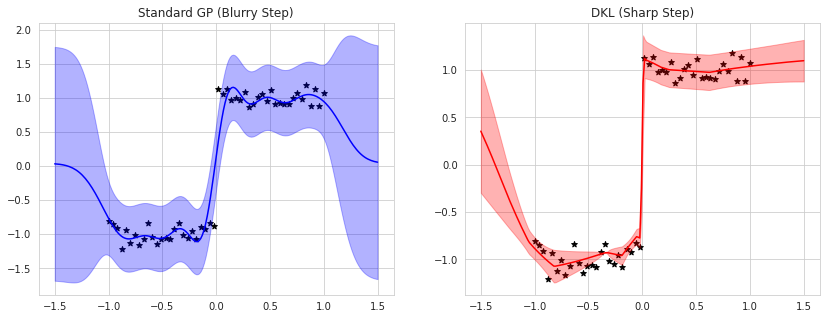

In [5]:
# 1. Generate Data
torch.manual_seed(42)
train_x = torch.linspace(-1, 1, 50).unsqueeze(-1)
train_y = (train_x.sign() + 0.1 * torch.randn_like(train_x)).squeeze()

# 2. Train Models
print("Training Standard GP...")
like_gp = gpytorch.likelihoods.GaussianLikelihood()
model_gp = StandardGP(train_x, train_y, like_gp)
train_model(model_gp, like_gp, train_x, train_y, iterations=100)

print("Training DKL...")
like_dkl = gpytorch.likelihoods.GaussianLikelihood()
model_dkl = DKLModel(train_x, train_y, like_dkl, input_dim=1)
train_model(model_dkl, like_dkl, train_x, train_y, iterations=200, lr=0.05)

# 3. Plotting
model_gp.eval(); like_gp.eval()
model_dkl.eval(); like_dkl.eval()
with torch.no_grad():
    test_x = torch.linspace(-1.5, 1.5, 200).unsqueeze(-1)
    pred_gp = like_gp(model_gp(test_x))
    pred_dkl = like_dkl(model_dkl(test_x))

    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # GP Plot
    ax1.scatter(train_x, train_y, c='black', marker='*', label="Data")
    ax1.plot(test_x, pred_gp.mean, 'b', label="Mean")
    ax1.fill_between(test_x.squeeze(), pred_gp.mean - 2*pred_gp.stddev, pred_gp.mean + 2*pred_gp.stddev, alpha=0.3, color='blue')
    ax1.set_title("Standard GP (Blurry Step)")

    # DKL Plot
    ax2.scatter(train_x, train_y, c='black', marker='*', label="Data")
    ax2.plot(test_x, pred_dkl.mean, 'r', label="Mean")
    ax2.fill_between(test_x.squeeze(), pred_dkl.mean - 2*pred_dkl.stddev, pred_dkl.mean + 2*pred_dkl.stddev, alpha=0.3, color='red')
    ax2.set_title("DKL (Sharp Step)")
    
    plt.show()

## 4. Example 2: The 2D Discontinuity

Standard kernels are isotropic (circular). DKL can learn diagonal or complex boundaries.

Training 2D GP...
Training 2D DKL...


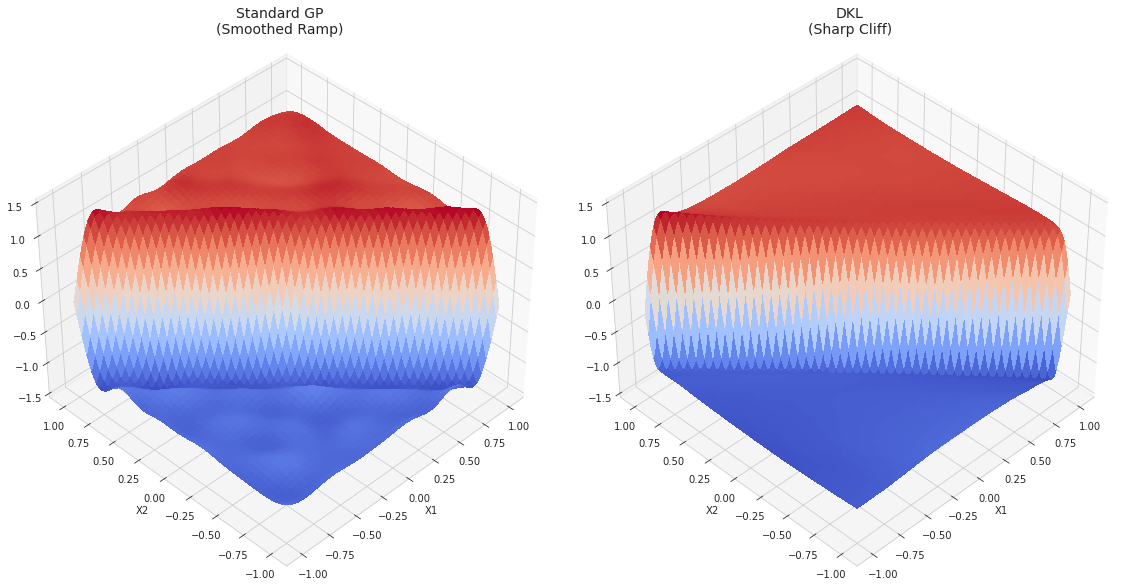

In [7]:
# 1. Generate 2D Data (Diagonal Split)
x1 = torch.linspace(-1, 1, 20)
x2 = torch.linspace(-1, 1, 20)
grid_x1, grid_x2 = torch.meshgrid(x1, x2, indexing='ij')
train_x_2d = torch.stack([grid_x1.reshape(-1), grid_x2.reshape(-1)], -1)
train_y_2d = (train_x_2d.sum(dim=1).sign() + 0.05 * torch.randn(400)).squeeze()

# 2. Train Models
print("Training 2D GP...")
like_gp2 = gpytorch.likelihoods.GaussianLikelihood()
model_gp2 = StandardGP(train_x_2d, train_y_2d, like_gp2)
train_model(model_gp2, like_gp2, train_x_2d, train_y_2d, iterations=100, verbose=False)

print("Training 2D DKL...")
like_dkl2 = gpytorch.likelihoods.GaussianLikelihood()
model_dkl2 = DKLModel(train_x_2d, train_y_2d, like_dkl2, input_dim=2)
train_model(model_dkl2, like_dkl2, train_x_2d, train_y_2d, iterations=200, lr=0.05, verbose=False)

# 3. Plotting
model_gp2.eval(); like_gp2.eval()
model_dkl2.eval(); like_dkl2.eval()
with torch.no_grad():
    test_x1 = torch.linspace(-1, 1, 50)
    grid_t1, grid_t2 = torch.meshgrid(test_x1, test_x1, indexing='ij')
    test_x_2d = torch.stack([grid_t1.reshape(-1), grid_t2.reshape(-1)], -1)
    
    pred_gp2 = like_gp2(model_gp2(test_x_2d)).mean.reshape(50, 50)
    pred_dkl2 = like_dkl2(model_dkl2(test_x_2d)).mean.reshape(50, 50)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].contourf(grid_t1, grid_t2, pred_gp2, cmap='coolwarm', levels=20)
    ax[0].set_title("Standard GP (Soft Boundary)")
    ax[1].contourf(grid_t1, grid_t2, pred_dkl2, cmap='coolwarm', levels=20)
    ax[1].set_title("DKL (Sharp Diagonal Boundary)")
    plt.show()

## 5. Neural Architecture Search (NAS)

Here we perform a "Mini-NAS" to see how the choice of Neural Network affects the GP.
We calculate **RMSE** (Accuracy) and **NLL** (Calibration/Uncertainty).

* **Overfitting:** Low RMSE, High NLL (Confident but wrong).
* **Underfitting:** High RMSE.

Model Name           | Test RMSE  | Test NLL  
--------------------------------------------------
Tiny (Linear)        | 0.1475     | -12.6196


/home/simon/.local/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/home/simon/.local/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
/home/simon/.local/lib/python3.10/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


Shallow (10)         | FAILED      | Matrix not positive ...
Standard (50,50)     | FAILED      | Matrix not positive ...
Deep (50,50,50)      | 0.1552     | -20.1562
Wide (1000)          | 0.1687     | -20.8685
Tanh (50,50)         | 0.1359     | -23.0110


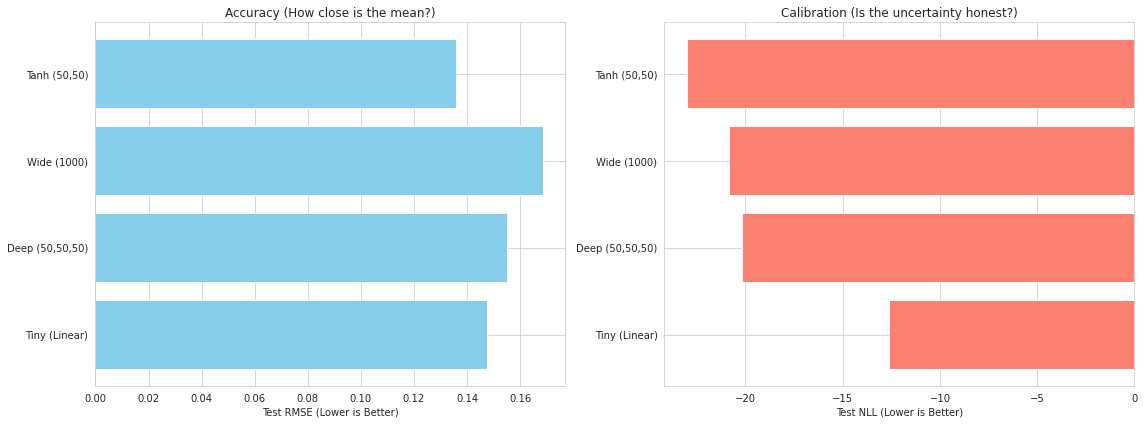

In [6]:
import torch
import torch.nn as nn
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# --- STABILITY CHECKLIST ---
# 1. PRECISION: GPs involve matrix inversions that are very sensitive to rounding errors.
#    Standard float32 often fails. We force float64 (Double Precision) globally.
torch.set_default_dtype(torch.float64)

# --- 1. Dynamic Model Definition ---
class DynamicDKL(gpytorch.models.ExactGP):
    """
    A Deep Kernel Learning model that can dynamically build different 
    Neural Network architectures on the fly.
    """
    def __init__(self, train_x, train_y, likelihood, hidden_layers=[50, 50], activation='relu'):
        super(DynamicDKL, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        
        # --- Build the Neural Network ---
        layers = []
        input_dim = train_x.shape[-1]
        
        # Loop through the list of hidden layer sizes to stack Linear layers
        for h_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, h_dim))
            
            # Select Activation Function
            if activation == 'relu': 
                layers.append(nn.ReLU())
            elif activation == 'tanh': 
                layers.append(nn.Tanh()) # Tanh is smoother, sometimes better for GPs
                
            input_dim = h_dim
            
        # --- Bottleneck Layer ---
        # We project the high-dim features down to 2 dimensions.
        # This 2D space is where the Kernel calculates similarity.
        layers.append(nn.Linear(input_dim, 2))
        
        self.feature_extractor = nn.Sequential(*layers)
        
        # The Kernel is applied to the output of the NN
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))

    def forward(self, x):
        # 1. Pass input through Neural Network
        projected_x = self.feature_extractor(x)
        
        # --- STABILITY HACK: Normalization ---
        # GPs struggle if input values are very large (e.g., > 100).
        # Neural networks can output large values. We force the latent space 
        # to stay between -1 and 1 to keep the RBF kernel gradients stable.
        projected_x = projected_x - projected_x.min(0)[0]
        projected_x = 2 * (projected_x / projected_x.max(0)[0]) - 1
        
        # 2. Standard GP Logic on the projected features
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(projected_x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# --- 2. Helper Functions ---
def train_model(model, likelihood, train_x, train_y, iterations=100, lr=0.05):
    """
    Standard PyTorch training loop. Optimizes NN weights AND Kernel Hyperparameters.
    """
    model.train(); likelihood.train()
    # Adam optimizes both the Neural Net weights and the GP hyperparameters (lengthscale, noise)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(iterations):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y) # Negative Log Likelihood
        loss.backward()
        optimizer.step()

def evaluate_metrics(model, likelihood, x, y):
    """
    Calculates RMSE (Accuracy) and NLL (Calibration/Uncertainty).
    """
    model.eval(); likelihood.eval()
    
    # --- STABILITY HACK: Jitter ---
    # Sometimes the NN maps different inputs to the EXACT same point (Feature Collapse).
    # This creates duplicate rows in the kernel matrix, making it singular (un-invertible).
    # 'cholesky_jitter' adds noise (1e-2) to the diagonal to force invertibility.
    with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-2): 
        pred = likelihood(model(x))
        rmse = torch.sqrt(torch.mean((pred.mean - y)**2)).item()
        
        # NLL: Penalizes the model if the truth is outside its confidence interval.
        nll = -pred.log_prob(y).mean().item()
    return rmse, nll

# --- 3. Data Generation ---
torch.manual_seed(101)
# NOTE: dtype=torch.float64 is crucial here to match the global setting
X_full = torch.linspace(-1, 1, 100, dtype=torch.float64).unsqueeze(-1)
y_full = (X_full.sign() + 0.1 * torch.randn_like(X_full)).squeeze()

# 70/30 Train/Test Split
indices = torch.randperm(len(X_full))
split = int(0.7 * len(X_full))
train_idx, test_idx = indices[:split], indices[split:]
train_x, train_y = X_full[train_idx], y_full[train_idx]
test_x, test_y = X_full[test_idx], y_full[test_idx]

# --- 4. The Architecture Search Loop ---
architectures = [
    {'name': 'Tiny (Linear)', 'layers': [2], 'act': 'relu'},       # Underfitting risk
    {'name': 'Shallow (10)', 'layers': [10], 'act': 'relu'},       # Simple non-linear
    {'name': 'Standard (50,50)', 'layers': [50, 50], 'act': 'relu'}, # "Goldilocks" zone?
    {'name': 'Deep (50,50,50)', 'layers': [50, 50, 50], 'act': 'relu'}, # Harder to train
    {'name': 'Wide (1000)', 'layers': [1000], 'act': 'relu'},      # Overfitting risk
    {'name': 'Tanh (50,50)', 'layers': [50, 50], 'act': 'tanh'}    # Different activation
]

results = []

print(f"{'Model Name':<20} | {'Test RMSE':<10} | {'Test NLL':<10}")
print("-" * 50)

for arch in architectures:
    try:
        # Re-initialize likelihood for every new model
        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        
        model = DynamicDKL(train_x, train_y, likelihood, 
                           hidden_layers=arch['layers'], 
                           activation=arch['act'])
        
        # --- CRITICAL: CASTING ---
        # Even though we set default float64, new modules sometimes default to float32.
        # We explicitly cast .double() to ensure matrix multiplications don't crash.
        model = model.double()
        likelihood = likelihood.double()
        
        # Train
        train_model(model, likelihood, train_x, train_y, iterations=150)
        
        # Evaluate
        t_rmse, t_nll = evaluate_metrics(model, likelihood, test_x, test_y)
        
        results.append({'name': arch['name'], 'rmse': t_rmse, 'nll': t_nll})
        print(f"{arch['name']:<20} | {t_rmse:.4f}     | {t_nll:.4f}")
        
    except Exception as e:
        # Catch numerical errors (Singular Matrix) without stopping the whole loop
        print(f"{arch['name']:<20} | FAILED      | {str(e)[:20]}...")

# --- 5. Visualization ---
if len(results) > 0:
    names = [r['name'] for r in results]
    rmses = [r['rmse'] for r in results]
    nlls = [r['nll'] for r in results]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Logic to handle failed runs (NaNs) in plotting
    valid_indices = [i for i, val in enumerate(rmses) if not np.isnan(val)]
    valid_names = [names[i] for i in valid_indices]
    valid_rmses = [rmses[i] for i in valid_indices]
    valid_nlls = [nlls[i] for i in valid_indices]

    ax1.barh(valid_names, valid_rmses, color='skyblue')
    ax1.set_xlabel('Test RMSE (Lower is Better)')
    ax1.set_title('Accuracy (How close is the mean?)')

    ax2.barh(valid_names, valid_nlls, color='salmon')
    ax2.set_xlabel('Test NLL (Lower is Better)')
    ax2.set_title('Calibration (Is the uncertainty honest?)')
    
    plt.tight_layout()
    plt.show()

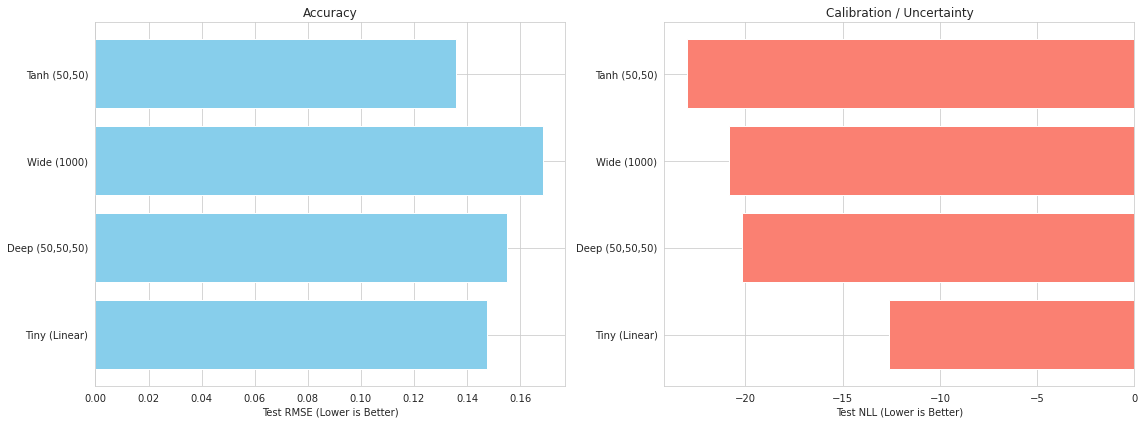

In [7]:
# Visualizing NAS Results
names = [r['name'] for r in results]
rmses = [r['rmse'] for r in results]
nlls = [r['nll'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.barh(names, rmses, color='skyblue')
ax1.set_xlabel('Test RMSE (Lower is Better)')
ax1.set_title('Accuracy')

ax2.barh(names, nlls, color='salmon')
ax2.set_xlabel('Test NLL (Lower is Better)')
ax2.set_title('Calibration / Uncertainty')
plt.tight_layout()
plt.show()

## 6. K-Fold Cross Validation

To ensure our results aren't just luck (due to the specific train/test split above), we use 5-Fold Cross Validation on the standard architecture.

In [8]:
# --- K-FOLD CROSS VALIDATION ---
# Why? A single train/test split can be lucky or unlucky. 
# Cross Validation rotates the data so every point gets to be in the "Test Set" once.
# This gives us a confidence interval (Mean +/- Std Dev) for our model's performance.

from sklearn.model_selection import KFold

k_folds = 5
kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
cv_rmse = []
cv_nll = []

print(f"Running {k_folds}-Fold CV on 'Standard (50,50)' DKL...")

# Ensure data is on CPU for splitting
# (scikit-learn sometimes struggles with GPU tensors, so we move to CPU first)
X_cv = X_full.cpu()
y_cv = y_full.cpu()

for fold, (train_ids, val_ids) in enumerate(kfold.split(X_cv)):
    # 1. Slice data based on the indices provided by KFold
    # We also enforce float64 (Double) here to be absolutely safe
    k_train_x = X_cv[train_ids].to(dtype=torch.float64)
    k_train_y = y_cv[train_ids].to(dtype=torch.float64)
    k_val_x = X_cv[val_ids].to(dtype=torch.float64)
    k_val_y = y_cv[val_ids].to(dtype=torch.float64)
    
    # 2. Re-Initialize the Model completely
    # If we didn't do this, we would be fine-tuning the previous fold's model (Data Leakage!)
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = DynamicDKL(k_train_x, k_train_y, likelihood, hidden_layers=[50, 50])
    
    # 3. CRITICAL: Force Double Precision
    # This aligns the Model weights (float64) with the Data (float64)
    model = model.double()
    likelihood = likelihood.double()
    
    try:
        # 4. Train
        # Note: We use the train_model function defined in the previous cell.
        train_model(model, likelihood, k_train_x, k_train_y, iterations=100, lr=0.05)
        
        # 5. Evaluate
        # Note: evaluate_metrics handles the 'jitter' internally
        v_rmse, v_nll = evaluate_metrics(model, likelihood, k_val_x, k_val_y)
        
        cv_rmse.append(v_rmse)
        cv_nll.append(v_nll)
        print(f"Fold {fold+1}: RMSE={v_rmse:.4f}, NLL={v_nll:.4f}")
        
    except Exception as e:
        # If a fold fails (Matrix Singularity), we log it but don't crash the script
        print(f"Fold {fold+1}: FAILED - {e}")

print("-" * 30)
if len(cv_rmse) > 0:
    print(f"Avg CV RMSE: {np.mean(cv_rmse):.4f} +/- {np.std(cv_rmse):.4f}")
    print(f"Avg CV NLL : {np.mean(cv_nll):.4f}  +/- {np.std(cv_nll):.4f}")
    print("\nInterpretation:")
    print("Low Variance (+/-) means the model is robust and not just 'getting lucky' on specific splits.")

Running 5-Fold CV on 'Standard (50,50)' DKL...
Fold 1: RMSE=0.0909, NLL=-19.1851
Fold 2: RMSE=0.1558, NLL=-18.2456
Fold 3: RMSE=0.2612, NLL=-17.2195
Fold 4: RMSE=0.2990, NLL=2.0612
Fold 5: RMSE=0.1613, NLL=-11.6156
------------------------------
Avg CV RMSE: 0.1936 +/- 0.0758
Avg CV NLL : -12.8409  +/- 7.9020

Interpretation:
Low Variance (+/-) means the model is robust and not just 'getting lucky' on specific splits.
